In [6]:
from pesummary.io import read
import matplotlib.pyplot as plt
import numpy as np

event_name = 'shiftRe_to_220_dw0.1w1_snr100_DSparam_Mirror'
# event_name ='shiftRe_to_220_dw0.01w1_snr100_DSparam_Mirror'
# event_name ='shiftRe_to_220_dw0.001w1_snr100_DSparam_Mirror'
# event_name ='shiftIm_to_220_dw0.1w1_snr100_DSparam_Mirror'
# event_name ='shiftIm_to_220_dw0.01w1_snr100_DSparam_Mirror'
# event_name ='shiftIm_to_220_dw0.001w1_snr100_DSparam_Mirror'

json_file_path = 'outdirs/outdir_' + event_name + '/' + event_name + '_result.json'
data = read(json_file_path, package='core')
posterior_samples = data.samples_dict
injection_parameters = data.injection_parameters

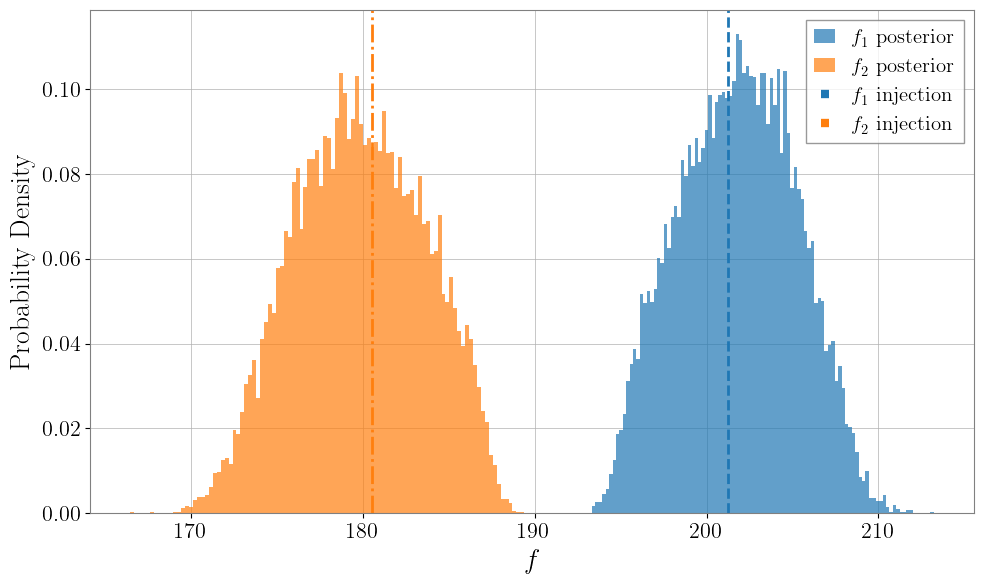

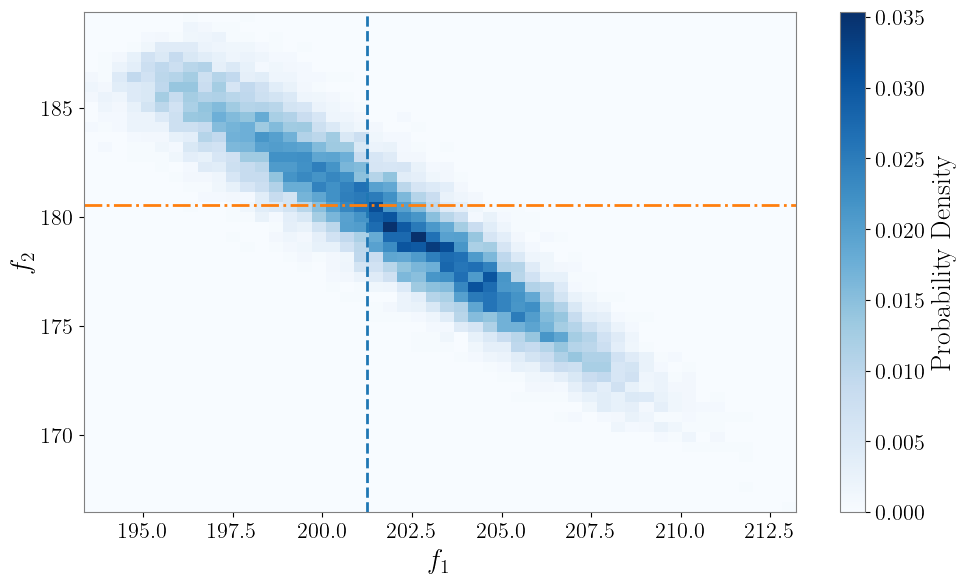

In [7]:
plt.style.use('~/research/my_plot_style.style')

plt.figure()
plt.hist(posterior_samples['f1'], bins=100, density=True, alpha=0.7, label=r'$f_1$ posterior', color='C0')
plt.hist(posterior_samples['f2'], bins=100, density=True, alpha=0.7, label=r'$f_2$ posterior', color='C1')
plt.axvline(injection_parameters['f1'], color='C0', linestyle='--', label=r'$f_1$ injection')
plt.axvline(injection_parameters['f2'], color='C1', linestyle='-.', label=r'$f_2$ injection')
plt.legend()
plt.xlabel(r'$f$')
plt.ylabel('Probability Density')
plt.show()

plt.figure()
plt.hist2d(posterior_samples['f1'], posterior_samples['f2'], bins=50, density=True, cmap='Blues')
plt.colorbar(label='Probability Density')
plt.axvline(injection_parameters['f1'], color='C0', linestyle='--', label=r'$f_1$ injection')
plt.axhline(injection_parameters['f2'], color='C1', linestyle='-.', label=r'$f_2$ injection')
plt.plot(np.linspace(min(posterior_samples['f1'].min(), posterior_samples['f2'].min()), max(posterior_samples['f1'].max(), posterior_samples['f2'].max()), 100), np.linspace(min(posterior_samples['f1'].min(), posterior_samples['f2'].min()), max(posterior_samples['f1'].max(), posterior_samples['f2'].max()), 100), color='k', linestyle=':', label='$f_1 = f_2$')
plt.xlabel(r'$f_1$')
plt.ylabel(r'$f_2$')
plt.show()